# Floor Strategy Optimizations

Five targeted experiments to reduce MaxDD without deleveraging.
Each is tested against the **hybrid baseline** (CAGR +19.4%, Sharpe 0.93, MaxDD -19.7%).

| # | Experiment | Hypothesis |
|---|---|---|
| 1 | Bull call spread | Sell OTM call to reduce net premium → better floor |
| 2 | Dynamic strike | Pick cheapest K where floor ≥ threshold instead of always ATM |
| 3 | Profit lock | Roll early when equity sits far above floor → lock gains |
| 4 | IV filter | Skip cycles when implied vol makes protection too expensive |
| 5 | DTE optimization | Minimize premium per day of coverage across available expiries |

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsll, load_tsll_calls, load_tsla_underlying, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline

tsll_spot  = load_tsll().set_index("Date")["Close"]
tsll_calls = load_tsll_calls()
tsll_lut   = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()
tsla_lut   = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

r_tsla     = tsla_spot.pct_change()
tsla_sigma = (r_tsla.rolling(21).std() * 252**0.5).ffill().bfill()
r_tsll     = tsll_spot.pct_change()
tsll_sigma = (r_tsll.rolling(21).std() * 252**0.5).ffill().bfill()

tsll_calls_vol = tsll_calls[tsll_calls["px_volume"] > 0].copy()
tsll_calls_vol["dte"] = (pd.to_datetime(tsll_calls_vol["expiry"]) - pd.to_datetime(tsll_calls_vol["date"])).dt.days
tsll_calls_vol["spot"] = tsll_calls_vol["date"].map(tsll_spot)
tsll_calls_vol["moneyness"] = tsll_calls_vol["strike"] / tsll_calls_vol["spot"]

first_tsll_date = tsll_calls_vol["date"].min()
sim_dates = tsll_spot.index[tsll_spot.index >= first_tsll_date]

TARGET_DTE  = 90
MAX_DTE     = 110
MIN_DTE     = 60
TSLL_LEVER  = 2.0
R_RF        = 0.05

print(f"Simulation: {sim_dates[0].date()} → {sim_dates[-1].date()}  ({len(sim_dates):,} days)")
print("Data loaded.")

Simulation: 2022-08-12 → 2026-06-10  (960 days)
Data loaded.


In [2]:
# ── Shared helpers ────────────────────────────────────────────────────────────

def bs_call_price(S, K, T, r, sigma):
    """Black-Scholes call price."""
    from scipy.stats import norm
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(S, K, T, r, market_price):
    """BS implied vol via Brent's method. Returns NaN if no solution."""
    intrinsic = max(S - K, 0.0)
    if market_price <= intrinsic or T <= 0:
        return float("nan")
    try:
        return brentq(lambda v: bs_call_price(S, K, T, r, v) - market_price,
                      1e-4, 10.0, xtol=1e-6)
    except Exception:
        return float("nan")

def _mtm_generic(pos, d, lut, spot_series):
    if d > pos["expiry"]:
        return max(float(spot_series.loc[d]) - pos["strike"], 0.0)
    px = lut.get((pos["raw_id"], d))
    return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

def quick_stats(eq, label):
    ret    = eq.pct_change().dropna()
    n_yrs  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1 / n_yrs) - 1
    sharpe = ret.mean() / ret.std() * 252**0.5
    maxdd  = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(maxdd)
    return {"Strategy": label, "CAGR": cagr, "Sharpe": sharpe, "Max DD": maxdd, "Calmar": calmar}

print("Helpers defined.")

Helpers defined.


In [3]:
# ── Baseline: hybrid guaranteed floor (re-run for fair comparison) ────────────
# Copied from guaranteed_floor_hybrid_sandbox to keep this notebook self-contained.

RELAX_MIN_DTE = 45
RELAX_MAX_DTE = 120
RELAX_MONO_LO = 0.80
RELAX_MONO_HI = 1.20

def _select_tsll_relaxed(d):
    spot = float(tsll_spot.loc[d]) if d in tsll_spot.index else None
    if spot is None:
        return None
    day = tsll_calls_vol[tsll_calls_vol["date"] == d]
    window = day[
        (day["dte"] >= RELAX_MIN_DTE) & (day["dte"] <= RELAX_MAX_DTE) &
        (day["moneyness"] >= RELAX_MONO_LO) & (day["moneyness"] <= RELAX_MONO_HI)
    ]
    if window.empty:
        return None
    window = window.copy()
    window["atm_dist"] = (window["moneyness"] - 1.0).abs()
    window["dte_dist"]  = (window["dte"] - TARGET_DTE).abs()
    return window.sort_values(["atm_dist", "dte_dist"]).iloc[0]

def simulate_baseline(sim_dates):
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100
    equity      = pd.Series(index=sim_dates, dtype=float)
    pos_tsll = pos_tsla = None
    option_pnl = short_pnl = 0.0
    S_prev = S_incep

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today
        expiry     = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        need_new   = (expiry is None) or (d > expiry)
        if pos_tsll:
            px = _mtm_generic(pos_tsll, d, tsll_lut, tsll_spot)
            option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]); pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px
        if need_new:
            pos_tsll = pos_tsla = None
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])
            row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                pos_tsll = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                            "expiry": row["expiry"], "n": n_contracts, "price": float(row["px_last"])}
            else:
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    pos_tsll = {"raw_id": row_r["raw_id"], "strike": float(row_r["strike"]),
                                "expiry": pd.Timestamp(row_r["expiry"]), "n": n_contracts,
                                "price": float(row_r["px_last"])}
                    T_l = max((pd.Timestamp(row_r["expiry"]) - d).days / 365.25, 1/365.25)
                    sigma_l = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5
                    delta_l = bs_delta(S_today, float(row_r["strike"]), T_l, R_RF, sigma_l)
                    gap_dd  = max(TSLL_LEVER * n_shares * S_today - delta_l * n_contracts * 100 * S_today, 0)
                    if gap_dd > 0:
                        row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                        if row_a is not None:
                            T_a = (row_a["expiry"] - d).days / 365.25
                            delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                            n_tsla  = gap_dd / (max(delta_a, 0.01) * 100 * S_tsla)
                            pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                        "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}
                else:
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}
        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("Baseline defined. Run next cell to execute.")

Baseline defined. Run next cell to execute.


In [4]:
equity_baseline = simulate_baseline(sim_dates)
results = [quick_stats(equity_baseline, "Baseline (hybrid)")]
curves  = {"Baseline (hybrid)": equity_baseline}
print(f"Baseline → CAGR={results[0]['CAGR']:+.1%}  Sharpe={results[0]['Sharpe']:.2f}  MaxDD={results[0]['Max DD']:.1%}")

Baseline → CAGR=+19.4%  Sharpe=0.93  MaxDD=-19.7%


---
## Optimization 1 — Bull Call Spread

Buy ATM call at K₁, **sell** OTM call at K₂ = K₁ × (1 + spread_pct).  
Net premium = C₁ − C₂ → floor improves by N × C₂.  
**Tradeoff:** above K₂ the hedge no longer grows — short loss above K₂ is uncapped again.  
Grid search over spread widths: 5%, 10%, 15%, 20% OTM.

In [5]:
def simulate_bull_spread(sim_dates, spread_pct=0.10):
    """
    Same as baseline TSLL-first fill, but on each cycle:
      - Buy  N/100 TSLL calls at K1 (ATM)
      - Sell N/100 TSLL calls at K2 = K1 * (1 + spread_pct)
    If K2 contract not available, fall back to single-leg ATM (no spread that cycle).
    """
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100

    equity     = pd.Series(index=sim_dates, dtype=float)
    pos_long   = None   # long ATM leg
    pos_short  = None   # short OTM leg (we sold this call)
    pos_tsla   = None   # TSLA fallback
    option_pnl = short_pnl = 0.0
    S_prev     = S_incep

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today

        expiry = pos_long["expiry"] if pos_long else (pos_tsla["expiry"] if pos_tsla else None)
        need_new = (expiry is None) or (d > expiry)

        # MTM all open positions
        if pos_long:
            px = _mtm_generic(pos_long, d, tsll_lut, tsll_spot)
            option_pnl += pos_long["n"] * 100 * (px - pos_long["price"]); pos_long["price"] = px
        if pos_short:   # we are SHORT this call → P&L is inverted
            px = _mtm_generic(pos_short, d, tsll_lut, tsll_spot)
            option_pnl -= pos_short["n"] * 100 * (px - pos_short["price"]); pos_short["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px

        if need_new:
            pos_long = pos_short = pos_tsla = None
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            # Try TSLL ATM (long leg)
            row1 = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row1 is not None:
                K1 = float(row1["strike"])
                K2_target = K1 * (1 + spread_pct)
                pos_long = {"raw_id": row1["raw_id"], "strike": K1,
                            "expiry": row1["expiry"], "n": n_contracts, "price": float(row1["px_last"])}

                # Find OTM leg with same expiry, closest strike to K2_target
                same_exp = tsll_calls[
                    (tsll_calls["date"] == d) &
                    (tsll_calls["expiry"] == row1["expiry"]) &
                    (tsll_calls["strike"] > K1) &
                    (tsll_calls["px_last"] > 0)
                ].copy()
                if not same_exp.empty:
                    same_exp["k2_dist"] = (same_exp["strike"] - K2_target).abs()
                    row2 = same_exp.sort_values("k2_dist").iloc[0]
                    pos_short = {"raw_id": row2["raw_id"], "strike": float(row2["strike"]),
                                 "expiry": row2["expiry"], "n": n_contracts, "price": float(row2["px_last"])}
            else:
                # TSLL not available → TSLA fallback (single leg, no spread)
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    pos_long = {"raw_id": row_r["raw_id"], "strike": float(row_r["strike"]),
                                "expiry": pd.Timestamp(row_r["expiry"]), "n": n_contracts,
                                "price": float(row_r["px_last"])}
                else:
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("Bull spread defined. Run next cell to grid search spread widths.")

Bull spread defined. Run next cell to grid search spread widths.


In [6]:
spread_grid = [0.05, 0.10, 0.15, 0.20]
spread_results = []

for pct in spread_grid:
    eq  = simulate_bull_spread(sim_dates, spread_pct=pct)
    row = quick_stats(eq, f"Bull spread {pct:.0%} OTM")
    spread_results.append((pct, eq, row))
    print(f"  spread={pct:.0%}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

# Pick best by Calmar
best_spread = max(spread_results, key=lambda x: x[2]["Calmar"])
print(f"\nBest spread: {best_spread[0]:.0%} OTM  (Calmar={best_spread[2]['Calmar']:.2f})")
results.append(best_spread[2])
curves[best_spread[2]["Strategy"]] = best_spread[1]

  spread=5%  CAGR=+14.1%  Sharpe=0.50  MaxDD=-71.5%
  spread=10%  CAGR=+12.8%  Sharpe=0.48  MaxDD=-72.8%
  spread=15%  CAGR=+12.7%  Sharpe=0.48  MaxDD=-76.2%
  spread=20%  CAGR=+12.7%  Sharpe=0.49  MaxDD=-73.1%

Best spread: 5% OTM  (Calmar=0.20)


---
## Optimization 2 — Dynamic Strike Selection

Instead of always buying ATM, on each rebalance date scan all available TSLL strikes  
and pick the **highest K** (cheapest call) such that the floor remains ≥ `−floor_threshold × equity`.  
Grid search over floor thresholds: −5%, −10%, −15%, −20%.

In [7]:
def simulate_dynamic_strike(sim_dates, floor_threshold=-0.10):
    """
    On each rebalance date, pick the highest available TSLL strike K such that:
        N × (S₀ − K − C) / equity_now ≥ floor_threshold
    i.e. the cheapest call that still keeps the floor acceptable.
    Falls back to ATM if no strike satisfies the threshold.
    """
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100

    equity     = pd.Series(index=sim_dates, dtype=float)
    pos_tsll   = pos_tsla = None
    option_pnl = short_pnl = 0.0
    S_prev     = S_incep

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today
        equity_now = 1.0 + short_pnl + option_pnl

        expiry   = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        need_new = (expiry is None) or (d > expiry)

        if pos_tsll:
            px = _mtm_generic(pos_tsll, d, tsll_lut, tsll_spot)
            option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]); pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px

        if need_new:
            pos_tsll = pos_tsla = None
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            # Scan all TSLL calls within DTE window on this date
            day_calls = tsll_calls[
                (tsll_calls["date"] == d) &
                (tsll_calls["px_last"] > 0)
            ].copy()
            day_calls["dte"] = (pd.to_datetime(day_calls["expiry"]) - pd.to_datetime(d)).dt.days
            day_calls = day_calls[(day_calls["dte"] >= MIN_DTE) & (day_calls["dte"] <= MAX_DTE)]

            chosen = None
            if not day_calls.empty:
                # Compute floor ratio for each available strike; pick highest K meeting threshold
                day_calls = day_calls.copy()
                day_calls["floor_ratio"] = (
                    n_shares * (S_today - day_calls["strike"] - day_calls["px_last"]) / equity_now
                )
                eligible = day_calls[day_calls["floor_ratio"] >= floor_threshold]
                if eligible.empty:
                    # Nothing meets threshold — fall back to ATM (best available floor)
                    eligible = day_calls.sort_values("floor_ratio", ascending=False).head(1)
                # Among eligible, pick highest strike (cheapest premium)
                row = eligible.sort_values("strike", ascending=False).iloc[0]
                chosen = row

            if chosen is not None:
                pos_tsll = {"raw_id": chosen["raw_id"], "strike": float(chosen["strike"]),
                            "expiry": pd.Timestamp(chosen["expiry"]), "n": n_contracts,
                            "price": float(chosen["px_last"])}
            else:
                # No TSLL → TSLA fallback
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    pos_tsll = {"raw_id": row_r["raw_id"], "strike": float(row_r["strike"]),
                                "expiry": pd.Timestamp(row_r["expiry"]), "n": n_contracts,
                                "price": float(row_r["px_last"])}
                else:
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("Dynamic strike defined. Run next cell to grid search thresholds.")

Dynamic strike defined. Run next cell to grid search thresholds.


In [8]:
threshold_grid = [-0.05, -0.10, -0.15, -0.20]
dyn_results = []

for thr in threshold_grid:
    eq  = simulate_dynamic_strike(sim_dates, floor_threshold=thr)
    row = quick_stats(eq, f"Dynamic strike floor≥{thr:.0%}")
    dyn_results.append((thr, eq, row))
    print(f"  threshold={thr:.0%}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

best_dyn = max(dyn_results, key=lambda x: x[2]["Calmar"])
print(f"\nBest threshold: {best_dyn[0]:.0%}  (Calmar={best_dyn[2]['Calmar']:.2f})")
results.append(best_dyn[2])
curves[best_dyn[2]["Strategy"]] = best_dyn[1]

  threshold=-5%  CAGR=-3.0%  Sharpe=0.08  MaxDD=-34.6%
  threshold=-10%  CAGR=-7.2%  Sharpe=0.01  MaxDD=-44.4%
  threshold=-15%  CAGR=-13.6%  Sharpe=-0.12  MaxDD=-58.4%
  threshold=-20%  CAGR=-7.5%  Sharpe=-0.04  MaxDD=-53.2%

Best threshold: -5%  (Calmar=-0.09)


---
## Optimization 3 — Profit Lock (Early Roll Trigger)

If intra-cycle equity rises more than `lock_pct` above the cycle's starting equity,  
close the position early and open a fresh cycle — locking in the gain and resetting the floor  
from the new (higher) equity base.  
Grid search over triggers: +10%, +15%, +20%, +25%.

In [9]:
def simulate_profit_lock(sim_dates, lock_pct=0.15):
    """
    Adds an intra-cycle early-roll trigger to the baseline:
    if equity_today > cycle_equity_start * (1 + lock_pct), close and reopen.
    """
    S_incep      = float(tsll_spot.loc[sim_dates[0]])
    n_shares     = 1.0 / S_incep
    n_contracts  = n_shares / 100

    equity       = pd.Series(index=sim_dates, dtype=float)
    pos_tsll     = pos_tsla = None
    option_pnl   = short_pnl = 0.0
    S_prev       = S_incep
    cycle_eq_start = 1.0

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today
        equity_now = 1.0 + short_pnl + option_pnl

        expiry   = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        expired  = (expiry is not None) and (d > expiry)
        locked   = (equity_now > cycle_eq_start * (1 + lock_pct)) and (expiry is not None)
        need_new = (expiry is None) or expired or locked

        if pos_tsll:
            px = _mtm_generic(pos_tsll, d, tsll_lut, tsll_spot)
            option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]); pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px

        if need_new:
            pos_tsll = pos_tsla = None
            cycle_eq_start = 1.0 + short_pnl + option_pnl
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                pos_tsll = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                            "expiry": row["expiry"], "n": n_contracts, "price": float(row["px_last"])}
            else:
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    pos_tsll = {"raw_id": row_r["raw_id"], "strike": float(row_r["strike"]),
                                "expiry": pd.Timestamp(row_r["expiry"]), "n": n_contracts,
                                "price": float(row_r["px_last"])}
                else:
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("Profit lock defined. Run next cell to grid search trigger levels.")

Profit lock defined. Run next cell to grid search trigger levels.


In [10]:
lock_grid = [0.10, 0.15, 0.20, 0.25]
lock_results = []

for pct in lock_grid:
    eq  = simulate_profit_lock(sim_dates, lock_pct=pct)
    row = quick_stats(eq, f"Profit lock +{pct:.0%}")
    lock_results.append((pct, eq, row))
    print(f"  trigger=+{pct:.0%}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

best_lock = max(lock_results, key=lambda x: x[2]["Calmar"])
print(f"\nBest trigger: +{best_lock[0]:.0%}  (Calmar={best_lock[2]['Calmar']:.2f})")
results.append(best_lock[2])
curves[best_lock[2]["Strategy"]] = best_lock[1]

  trigger=+10%  CAGR=+7.7%  Sharpe=0.43  MaxDD=-27.5%
  trigger=+15%  CAGR=+13.9%  Sharpe=0.67  MaxDD=-22.5%
  trigger=+20%  CAGR=+9.2%  Sharpe=0.48  MaxDD=-25.0%
  trigger=+25%  CAGR=+7.2%  Sharpe=0.40  MaxDD=-30.8%

Best trigger: +15%  (Calmar=0.62)


---
## Optimization 4 — Implied Volatility Filter

Compute the ATM implied vol from the selected TSLL call on each rebalance date.  
If IV > threshold, skip the cycle entirely (no call, no hedge, no new position) — wait for next natural roll date.  
Grid search over IV thresholds: 60%, 80%, 100%, 120%.

In [11]:
def simulate_iv_filter(sim_dates, iv_threshold=0.80):
    """
    Skip opening a new hedge cycle when the ATM TSLL call's implied vol exceeds iv_threshold.
    In skipped cycles the short runs naked (no call) until the next natural roll date.
    """
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100

    equity     = pd.Series(index=sim_dates, dtype=float)
    pos_tsll   = pos_tsla = None
    option_pnl = short_pnl = 0.0
    S_prev     = S_incep
    skipped_until = None   # date until which we stay unhedged after a skip

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today

        expiry   = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        need_new = (expiry is None) or (d > expiry)

        if pos_tsll:
            px = _mtm_generic(pos_tsll, d, tsll_lut, tsll_spot)
            option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]); pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px

        if need_new:
            pos_tsll = pos_tsla = None
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            row = select_contract(tsll_calls, tsll_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                T_opt = (row["expiry"] - d).days / 365.25
                iv    = implied_vol(S_today, float(row["strike"]), T_opt, R_RF, float(row["px_last"]))
                if not pd.isna(iv) and iv > iv_threshold:
                    pass   # skip — too expensive, run naked short this cycle
                else:
                    pos_tsll = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                                "expiry": row["expiry"], "n": n_contracts, "price": float(row["px_last"])}
            else:
                row_r = _select_tsll_relaxed(d)
                if row_r is not None:
                    pos_tsll = {"raw_id": row_r["raw_id"], "strike": float(row_r["strike"]),
                                "expiry": pd.Timestamp(row_r["expiry"]), "n": n_contracts,
                                "price": float(row_r["px_last"])}
                else:
                    row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                    if row_a is not None:
                        T_a = (row_a["expiry"] - d).days / 365.25
                        delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                        n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                        pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                    "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("IV filter defined. Run next cell to grid search thresholds.")

IV filter defined. Run next cell to grid search thresholds.


In [12]:
iv_grid = [0.60, 0.80, 1.00, 1.20]
iv_results = []

for thr in iv_grid:
    eq  = simulate_iv_filter(sim_dates, iv_threshold=thr)
    row = quick_stats(eq, f"IV filter ≤{thr:.0%}")
    iv_results.append((thr, eq, row))
    print(f"  IV≤{thr:.0%}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

best_iv = max(iv_results, key=lambda x: x[2]["Calmar"])
print(f"\nBest IV threshold: ≤{best_iv[0]:.0%}  (Calmar={best_iv[2]['Calmar']:.2f})")
results.append(best_iv[2])
curves[best_iv[2]["Strategy"]] = best_iv[1]

  IV≤60%  CAGR=+2.7%  Sharpe=0.26  MaxDD=-50.4%
  IV≤80%  CAGR=-7.4%  Sharpe=0.14  MaxDD=-66.6%
  IV≤100%  CAGR=+18.3%  Sharpe=0.74  MaxDD=-20.4%
  IV≤120%  CAGR=+10.6%  Sharpe=0.50  MaxDD=-32.3%

Best IV threshold: ≤100%  (Calmar=0.90)


---
## Optimization 5 — DTE Optimization

Instead of targeting 90 DTE, on each rebalance date scan all available expiries and  
pick the one that minimizes **premium per day of coverage** (C / DTE) while the floor  
remains ≥ −10%. This exploits the volatility term structure.  
Grid search over DTE windows: 45–90, 60–120, 60–180 days.

In [13]:
def simulate_dte_opt(sim_dates, min_dte=60, max_dte=180, floor_threshold=-0.10):
    """
    On each rebalance date, scan all available TSLL ATM calls across expiries
    within [min_dte, max_dte]. For each expiry, find the closest-to-ATM strike
    and compute premium per day (C / DTE). Pick the expiry minimizing C/DTE
    subject to floor ≥ floor_threshold.
    """
    S_incep     = float(tsll_spot.loc[sim_dates[0]])
    n_shares    = 1.0 / S_incep
    n_contracts = n_shares / 100

    equity     = pd.Series(index=sim_dates, dtype=float)
    pos_tsll   = pos_tsla = None
    option_pnl = short_pnl = 0.0
    S_prev     = S_incep

    for d in sim_dates:
        S_today    = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today
        equity_now = 1.0 + short_pnl + option_pnl

        expiry   = pos_tsll["expiry"] if pos_tsll else (pos_tsla["expiry"] if pos_tsla else None)
        need_new = (expiry is None) or (d > expiry)

        if pos_tsll:
            px = _mtm_generic(pos_tsll, d, tsll_lut, tsll_spot)
            option_pnl += pos_tsll["n"] * 100 * (px - pos_tsll["price"]); pos_tsll["price"] = px
        if pos_tsla:
            px = _mtm_generic(pos_tsla, d, tsla_lut, tsla_spot)
            option_pnl += pos_tsla["n"] * 100 * (px - pos_tsla["price"]); pos_tsla["price"] = px

        if need_new:
            pos_tsll = pos_tsla = None
            sigma_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
            S_tsla  = float(tsla_spot.loc[d])

            # Scan all TSLL calls in DTE window, find best C/DTE per expiry
            day_calls = tsll_calls[
                (tsll_calls["date"] == d) & (tsll_calls["px_last"] > 0)
            ].copy()
            day_calls["dte"] = (pd.to_datetime(day_calls["expiry"]) - pd.to_datetime(d)).dt.days
            day_calls = day_calls[(day_calls["dte"] >= min_dte) & (day_calls["dte"] <= max_dte)].copy()
            day_calls["atm_dist"]    = (day_calls["strike"] / S_today - 1.0).abs()
            day_calls["floor_ratio"] = n_shares * (S_today - day_calls["strike"] - day_calls["px_last"]) / equity_now
            day_calls["cost_per_day"] = day_calls["px_last"] / day_calls["dte"]

            # For each expiry, pick closest-to-ATM strike meeting floor threshold
            chosen = None
            if not day_calls.empty:
                eligible = day_calls[day_calls["floor_ratio"] >= floor_threshold]
                if eligible.empty:
                    eligible = day_calls  # relax threshold if nothing qualifies
                # Among eligible, pick the one with lowest cost_per_day
                # (break ties by ATM proximity)
                best_exp = eligible.sort_values(["cost_per_day", "atm_dist"]).iloc[0]
                chosen = best_exp

            if chosen is not None:
                pos_tsll = {"raw_id": chosen["raw_id"], "strike": float(chosen["strike"]),
                            "expiry": pd.Timestamp(chosen["expiry"]), "n": n_contracts,
                            "price": float(chosen["px_last"])}
            else:
                row_a = select_contract(tsla_calls, tsla_spot, d, "ATM", TARGET_DTE, max_dte=MAX_DTE)
                if row_a is not None:
                    T_a = (row_a["expiry"] - d).days / 365.25
                    delta_a = bs_delta(S_tsla, float(row_a["strike"]), T_a, R_RF, sigma_a)
                    n_tsla  = (TSLL_LEVER * n_shares * S_today) / (max(delta_a, 0.01) * 100 * S_tsla)
                    pos_tsla = {"raw_id": row_a["raw_id"], "strike": float(row_a["strike"]),
                                "expiry": row_a["expiry"], "n": n_tsla, "price": float(row_a["px_last"])}

        equity.loc[d] = 1.0 + short_pnl + option_pnl
    return equity / equity.iloc[0]

print("DTE optimization defined. Run next cell to grid search DTE windows.")

DTE optimization defined. Run next cell to grid search DTE windows.


In [14]:
dte_grid = [(45, 90), (60, 120), (60, 180)]
dte_results = []

for mn, mx in dte_grid:
    eq  = simulate_dte_opt(sim_dates, min_dte=mn, max_dte=mx)
    row = quick_stats(eq, f"DTE opt {mn}-{mx}d")
    dte_results.append(((mn, mx), eq, row))
    print(f"  DTE {mn}-{mx}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  MaxDD={row['Max DD']:.1%}")

best_dte = max(dte_results, key=lambda x: x[2]["Calmar"])
print(f"\nBest window: {best_dte[0][0]}-{best_dte[0][1]}d  (Calmar={best_dte[2]['Calmar']:.2f})")
results.append(best_dte[2])
curves[best_dte[2]["Strategy"]] = best_dte[1]

  DTE 45-90  CAGR=-1.1%  Sharpe=0.15  MaxDD=-38.6%
  DTE 60-120  CAGR=-6.7%  Sharpe=0.03  MaxDD=-38.3%
  DTE 60-180  CAGR=+8.5%  Sharpe=0.43  MaxDD=-28.7%

Best window: 60-180d  (Calmar=0.30)


  OPTIMIZATION RESULTS  (best variant of each, vs baseline)
                            CAGR Sharpe  Max DD Calmar
Strategy                                              
Baseline (hybrid)         +19.4%   0.93  -19.7%   0.99
Bull spread 5% OTM        +14.1%   0.50  -71.5%   0.20
Dynamic strike floor≥-5%   -3.0%   0.08  -34.6%  -0.09
Profit lock +15%          +13.9%   0.67  -22.5%   0.62
IV filter ≤100%           +18.3%   0.74  -20.4%   0.90
DTE opt 60-180d            +8.5%   0.43  -28.7%   0.30
Note: frictionless — no bid-ask, borrow cost, or transaction costs


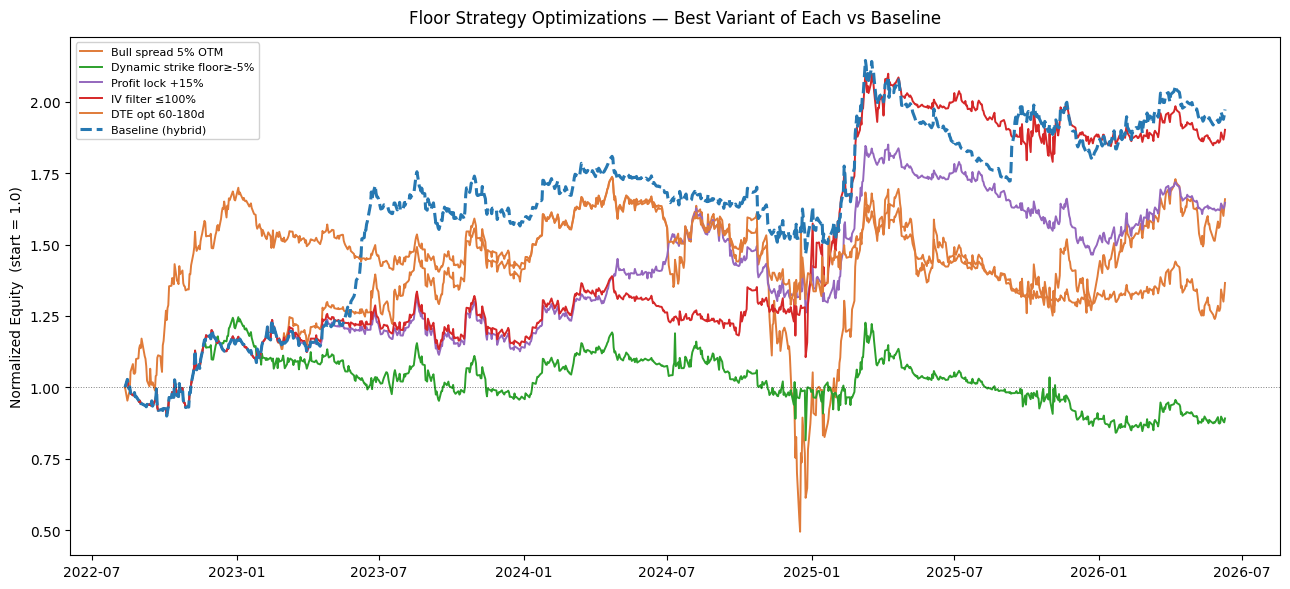


Saved → observations/strategies/sandbox/floor_optimizations.png


In [15]:
# ── Final comparison table ────────────────────────────────────────────────────
tbl = pd.DataFrame(results)
tbl["CAGR"]   = tbl["CAGR"].map("{:+.1%}".format)
tbl["Sharpe"] = tbl["Sharpe"].map("{:.2f}".format)
tbl["Max DD"] = tbl["Max DD"].map("{:.1%}".format)
tbl["Calmar"] = tbl["Calmar"].map("{:.2f}".format)

print("=" * 70)
print("  OPTIMIZATION RESULTS  (best variant of each, vs baseline)")
print("=" * 70)
print(tbl.set_index("Strategy").to_string())
print("=" * 70)
print("Note: frictionless — no bid-ask, borrow cost, or transaction costs")

# ── Equity curve comparison plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

styles = [
    ("Baseline (hybrid)",  "#2678B2", 2.2, "-"),
]
colors = ["#E07B39", "#2CA02C", "#9467BD", "#D62728"]
for i, (label, eq) in enumerate([(k, v) for k, v in curves.items() if k != "Baseline (hybrid)"]):
    ax.plot(eq.index, eq.values, label=label, color=colors[i % len(colors)],
            linewidth=1.4, linestyle="-")

ax.plot(equity_baseline.index, equity_baseline.values,
        label="Baseline (hybrid)", color="#2678B2", linewidth=2.2, linestyle="--")

ax.axhline(1.0, color="black", linestyle=":", linewidth=0.7, alpha=0.5)
ax.set_title("Floor Strategy Optimizations — Best Variant of Each vs Baseline",
             fontsize=12, pad=10)
ax.set_ylabel("Normalized Equity  (start = 1.0)", fontsize=10)
ax.legend(fontsize=8, framealpha=0.9)

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "floor_optimizations.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out.relative_to(ROOT)}")